# Stage 3 - Vessel Attribution (AIS correlation)

**Project:** oiltrace / SpillTrace - SIH 2026, problem statement SIH26143 (NTRO)

Stage 1 detects an oil slick in SAR satellite imagery. Stage 2 traces the slick
backwards through wind and current data to estimate **where and when** the oil
was released. Stage 3 - this notebook - takes that estimated origin and asks
**which ship was there at the time**, using AIS (Automatic Identification System)
ship-tracking data.

The answer is a **ranked list of suspects with a score breakdown**, not an
identification. AIS attribution is circumstantial evidence: it says a vessel's
track is consistent with the spill, which is a reason to investigate it.

### What this notebook does
1. Takes the estimated origin and time window handed over by Stage 2.
2. Loads AIS data (synthetic here - see the note at the end).
3. Filters the fleet down to vessels that were plausibly nearby.
4. Scores every candidate on four factors and ranks them.
5. Verifies the scoring finds a vessel that was **planted** as the known culprit.
6. Plots the candidate tracks and the suspect's behaviour around the spill time.
7. Checks the result holds across many randomised scenarios.

All logic lives in `attribution.py`; this notebook only calls it, so the backend
gets the same behaviour by importing the module.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# attribution.py sits next to this notebook.
sys.path.insert(0, str(Path.cwd()))
import attribution as attr

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)

print(f"python     : {sys.version.split()[0]}")
print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
print(f"attribution: {attr.__file__}")

python     : 3.12.0
pandas     : 3.0.5
numpy      : 2.4.6
attribution: F:\Events\SIH 2026\OilTrace - Development\ml\attribution\attribution.py


---
## 1. The Stage 2 handover

Stage 2's backward drift trace produced an estimated release point and time for
the Persian Gulf demo scenario - the same region Stage 1's Sentinel-1 training
imagery covers, so all three stages work over the same water. Those numbers are
the only input Stage 3 needs from
the rest of the pipeline:

| Quantity | Value | Source |
|---|---|---|
| Estimated origin | 51.50 E, 26.50 N | Stage 2 backward trace (centroid of back-traced particles) |
| Estimated origin time | 2026-08-26 12:00 | detection time (2026-08-27 12:00) minus the 24 h trace duration |
| Spill time window | origin time +/- 3 h | uncertainty allowance on the estimate |

The window matters as much as the point: a backward drift trace gives a *region*
and a *period*, never an exact spot and instant, so Stage 3 is built to work
with an uncertain estimate rather than a precise one.

In [2]:
ORIGIN_LON = attr.DEMO_ORIGIN_LON        # 51.50 E - from Stage 2
ORIGIN_LAT = attr.DEMO_ORIGIN_LAT        # 26.50 N - from Stage 2
WINDOW_START, WINDOW_END = attr.DEMO_SPILL_WINDOW

print(f"Estimated origin     : {ORIGIN_LON:.4f} E, {ORIGIN_LAT:.4f} N")
print(f"Estimated spill window: {WINDOW_START}  ->  {WINDOW_END}")
print(f"Search radius        : {attr.DEFAULT_RADIUS_KM:.0f} km")
print(f"Time buffer          : {attr.DEFAULT_TIME_BUFFER_HOURS:.0f} h either side of the window")

Estimated origin     : 51.5000 E, 26.5000 N
Estimated spill window: 2026-08-26 09:00:00  ->  2026-08-26 15:00:00
Search radius        : 50 km
Time buffer          : 6 h either side of the window


---
## 2. Load the AIS data

`load_ais_data()` reads a CSV and normalises it: it renames common column
variants to the marinecadastre.gov schema (`mmsi` / `lat` / `basedatetime` and
friends), parses timestamps, coerces numerics, drops rows missing the required
fields, and replaces the AIS "not available" sentinel values (SOG 102.3,
COG 360, Heading 511) with nulls so they are not mistaken for real readings.

The file loaded here is **synthetic** - generated by
`generate_synthetic_ais_data()`, which plants exactly one culprit vessel in
otherwise unrelated traffic. That is what makes the check in section 5 possible.
Swapping in a real marinecadastre.gov extract means changing this one path.

In [3]:
AIS_CSV = Path("data/synthetic_ais_persian_gulf.csv")

ais_df = attr.load_ais_data(AIS_CSV)

print(f"{len(ais_df):,} AIS reports from {ais_df['MMSI'].nunique()} vessels")
print(f"time span : {ais_df['BaseDateTime'].min()}  ->  {ais_df['BaseDateTime'].max()}")
print(f"lon range : {ais_df['LON'].min():.3f} to {ais_df['LON'].max():.3f}")
print(f"lat range : {ais_df['LAT'].min():.3f} to {ais_df['LAT'].max():.3f}")
print()
print("vessel types present:")
print(ais_df.groupby('VesselType')['MMSI'].nunique().sort_values(ascending=False).to_string())
print()
ais_df.head()

2,787 AIS reports from 20 vessels
time span : 2026-08-26 00:00:00  ->  2026-08-27 00:00:00
lon range : 50.705 to 52.699
lat range : 26.102 to 27.299

vessel types present:
VesselType
tanker       6
passenger    6
fishing      4
cargo        4



,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,VesselName,VesselType,Length,Draft,Status
0,210875340,2026-08-26 00:00:00,27.29291,50.74127,15.9,132.5,134.0,MS SAGAR,passenger,78.2,4.5,0
1,210875340,2026-08-26 00:10:00,27.26293,50.77780,16.3,133.1,134.0,MS SAGAR,passenger,78.2,4.5,0
2,210875340,2026-08-26 00:20:00,27.23219,50.81527,15.9,132.4,132.0,MS SAGAR,passenger,78.2,4.5,0
3,210875340,2026-08-26 00:30:00,27.20220,50.85179,15.9,134.4,132.0,MS SAGAR,passenger,78.2,4.5,0
4,210875340,2026-08-26 00:40:00,27.17217,50.88835,15.9,131.8,135.0,MS SAGAR,passenger,78.2,4.5,0


In [4]:
# The planted culprit, recorded when the dataset was generated. In a real
# investigation there is no such file - this exists only to grade the scoring.
GROUND_TRUTH = json.loads(Path("data/synthetic_ais_persian_gulf_ground_truth.json").read_text())

print(f"Planted culprit : {GROUND_TRUTH['suspect_name']} (MMSI {GROUND_TRUTH['suspect_mmsi']})")
print(f"Behaviour planted into its track:")
for key, value in GROUND_TRUTH["suspect_profile"].items():
    print(f"   {key:<28} {value}")

Planted culprit : MT KAVERI (MMSI 251765553)
Behaviour planted into its track:
   approach_course_deg          251.1
   escape_course_deg            306.1
   cruise_sog_knots             11.0
   discharge_sog_knots          3.5
   escape_sog_knots             14.0
   planted_speed_drop_knots     7.5
   planted_course_change_deg    55.0
   planted_ais_gap_minutes      90.0
   track_reports                41


---
## 3. Narrow the fleet: `filter_candidate_vessels()`

Scoring every vessel in a regional AIS feed would be wasteful - a real feed
covers thousands of ships over days. This step keeps only vessels that reported
a position **within `radius_km` of the origin** during the window plus a time
buffer.

Two details worth knowing:

* **The filter is cheap first, exact second.** It trims by time and by a
  bounding box before computing haversine distances, because the box test is
  arithmetic on two columns while the distance is trigonometry.
* **It returns each surviving vessel's whole in-window track, not only the
  reports inside the radius.** Scoring needs the approach - how the ship was
  moving *before* it reached the origin - so cropping to the radius would throw
  away the evidence.

In [5]:
candidates = attr.filter_candidate_vessels(
    ais_df,
    origin_lon=ORIGIN_LON,
    origin_lat=ORIGIN_LAT,
    time_window_start=WINDOW_START,
    time_window_end=WINDOW_END,
    radius_km=50,
    time_buffer_hours=6,
)

print(f"before: {ais_df['MMSI'].nunique():3} vessels, {len(ais_df):,} reports")
print(f"after : {candidates['MMSI'].nunique():3} vessels, {len(candidates):,} reports")
print(f"        ({100 * len(candidates) / len(ais_df):.0f}% of reports kept)")
print()

summary = candidates.groupby(["MMSI", "VesselName", "VesselType"]).agg(
    reports=("BaseDateTime", "size"),
    first_report=("BaseDateTime", "min"),
    last_report=("BaseDateTime", "max"),
).reset_index()
summary["closest_km"] = [
    round(float(np.min(attr.haversine_km(
        group["LON"].to_numpy(), group["LAT"].to_numpy(), ORIGIN_LON, ORIGIN_LAT))), 2)
    for _, group in candidates.groupby(["MMSI", "VesselName", "VesselType"])
]
summary.sort_values("closest_km")

before:  20 vessels, 2,787 reports
after :  13 vessels, 1,343 reports
        (48% of reports kept)



,MMSI,VesselName,VesselType,reports,first_report,last_report,closest_km
1,251765553,MT KAVERI,tanker,41,2026-08-26 08:00:00,2026-08-26 16:00:00,3.24
7,356553108,MT MERIDIAN,tanker,109,2026-08-26 03:00:00,2026-08-26 21:00:00,8.62
5,327121000,MS MEGHNA,passenger,106,2026-08-26 03:00:00,2026-08-26 21:00:00,10.43
0,210875340,MS SAGAR,passenger,106,2026-08-26 03:00:00,2026-08-26 21:00:00,13.83
12,745618834,MS KONKAN,passenger,109,2026-08-26 03:00:00,2026-08-26 21:00:00,22.69
2,290291614,FV KAVERI,fishing,109,2026-08-26 03:00:00,2026-08-26 21:00:00,23.00
6,334200422,MT TRIDENT,tanker,109,2026-08-26 03:00:00,2026-08-26 21:00:00,27.65
9,602438413,MS ZUARI,passenger,109,2026-08-26 03:00:00,2026-08-26 21:00:00,31.12
3,301034922,FV CASPIAN,fishing,109,2026-08-26 03:00:00,2026-08-26 21:00:00,32.92
8,466206671,FV ARABIAN,fishing,109,2026-08-26 03:00:00,2026-08-26 21:00:00,34.80


---
## 4. Score and rank: `rank_vessels()`

This is the single function the backend calls. Four factors are scored 0-1 and
combined into a weighted composite:

| Factor | Weight | What it measures |
|---|---|---|
| Proximity | 35% | Closest reported approach to the estimated origin |
| Trajectory | 30% | Whether the vessel's course pointed at the origin on the way in |
| Anomaly | 25% | Sharp speed drop, large course change, or AIS gap near the spill time |
| Vessel type | 10% | Prior likelihood by ship class - a tanker outranks a yacht |

Proximity leads because being there is the necessary condition. Trajectory is
close behind because it separates a ship that *ran through* the origin from one
that merely passed nearby. The anomaly term is what a human investigator
actually looks for - slowing down, turning away, or going dark at the moment of
a discharge - and it carries real weight (25%) rather than being a tiebreaker.
Vessel type is deliberately small: it is a prior, and weighting it heavily would
just rank tankers regardless of evidence.

Every sub-score is returned alongside the total, so any rank can be explained.

In [6]:
suspects = attr.rank_vessels(
    ais_df,
    origin_lon=ORIGIN_LON,
    origin_lat=ORIGIN_LAT,
    time_window_start=WINDOW_START,
    time_window_end=WINDOW_END,
    radius_km=50,
)

print(f"{len(suspects)} candidate vessels ranked\n")
header = (f"{'#':>2}  {'MMSI':<10} {'vessel':<14} {'type':<10} {'SCORE':>6} "
          f"{'prox':>6} {'traj':>6} {'anom':>6} {'vtyp':>6} {'closest km':>11}")
print(header)
print("-" * len(header))
for s in suspects:
    print(f"{s['rank']:>2}  {s['MMSI']:<10} {str(s['VesselName']):<14} {str(s['vessel_type']):<10} "
          f"{s['combined_score']:6.3f} {s['proximity_score']:6.3f} {s['trajectory_score']:6.3f} "
          f"{s['anomaly_score']:6.3f} {s['vessel_type_score']:6.3f} {s['closest_distance_km']:11.2f}")

13 candidate vessels ranked

 #  MMSI       vessel         type        SCORE   prox   traj   anom   vtyp  closest km
---------------------------------------------------------------------------------------
 1  251765553  MT KAVERI      tanker      0.941  0.954  0.999  0.828  1.000        3.24
 2  327121000  MS MEGHNA      passenger   0.646  0.807  0.900  0.294  0.200       10.43
 3  210875340  MS SAGAR       passenger   0.612  0.738  0.865  0.298  0.200       13.83
 4  356553108  MT MERIDIAN    tanker      0.567  0.845  0.538  0.039  1.000        8.62
 5  334200422  MT TRIDENT     tanker      0.537  0.456  0.689  0.285  1.000       27.65
 6  745618834  MS KONKAN      passenger   0.512  0.557  0.753  0.285  0.200       22.69
 7  290291614  FV KAVERI      fishing     0.488  0.551  0.654  0.294  0.250       23.00
 8  602438413  MS ZUARI       passenger   0.422  0.385  0.658  0.281  0.200       31.12
 9  628663284  MV SAGAR       cargo       0.422  0.281  0.569  0.294  0.800       36.25
10 

---
## 5. Does the scoring find the planted culprit?

The synthetic dataset has a known right answer: one vessel was built to have
run through the origin at the origin time, slow down, go dark, and turn away.
Every other track is unrelated traffic. If the scoring is sound, that vessel
comes first.

This is the sanity check the handoff document calls for, and it is a real test -
it fails loudly if a change to the weights or the sub-scores breaks the ranking.

In [7]:
top = suspects[0]
runner_up = suspects[1]

assert top["MMSI"] == GROUND_TRUTH["suspect_mmsi"], (
    f"SCORING FAILED: expected {GROUND_TRUTH['suspect_name']} at rank 1, got {top['VesselName']}"
)

print(f"PASS - the planted culprit ranks #1")
print(f"   #1 {top['VesselName']:<14} score {top['combined_score']:.3f}")
print(f"   #2 {runner_up['VesselName']:<14} score {runner_up['combined_score']:.3f}")
print(f"   margin: {top['combined_score'] - runner_up['combined_score']:+.3f}")

PASS - the planted culprit ranks #1
   #1 MT KAVERI      score 0.941
   #2 MS MEGHNA      score 0.646
   margin: +0.294


In [8]:
# The full explanation behind rank 1 - this is what the frontend would show.
print(f"TOP SUSPECT: {top['VesselName']}  (MMSI {top['MMSI']}, {top['vessel_type']})")
print("=" * 68)
print(f"  Composite suspicion score : {top['combined_score']:.3f}")
print(f"  AIS reports considered    : {top['n_positions']}  "
      f"({top['first_report_time']} -> {top['last_report_time']})")
print(f"  Course data source        : {top['course_source']}")
print()
print("  Factor breakdown")
for label, key, weight_key in [
    ("proximity  ", "proximity_score", "proximity"),
    ("trajectory ", "trajectory_score", "trajectory"),
    ("anomaly    ", "anomaly_score", "anomaly"),
    ("vessel type", "vessel_type_score", "vessel_type"),
]:
    weight = top["weights_used"][weight_key]
    bar = "#" * int(round(top[key] * 30))
    print(f"    {label} {top[key]:.3f} x {weight:.2f} = {top[key] * weight:.3f}  {bar}")
print()
print("  Supporting evidence")
print(f"    closest approach        : {top['closest_distance_km']:.2f} km "
      f"at {top['closest_approach_time']}")
td = top["trajectory_detail"]
print(f"    best course alignment  : {td['best_alignment_deg']} deg off the bearing to the origin, "
      f"{td['alignment_distance_km']} km out at {td['alignment_time']}")
ad = top["anomaly_detail"]
print(f"    sharp speed drop       : {ad['speed_drop_knots']} kn  (sub-score {ad['speed_drop_score']:.3f})")
print(f"    largest course change  : {ad['course_change_deg']} deg (sub-score {ad['course_change_score']:.3f})")
print(f"    longest AIS gap        : {ad['max_ais_gap_minutes']} min (sub-score {ad['ais_gap_score']:.3f})")
print()
print("  NOTE: circumstantial evidence for investigation, not an identification.")

TOP SUSPECT: MT KAVERI  (MMSI 251765553, tanker)
  Composite suspicion score : 0.941
  AIS reports considered    : 41  (2026-08-26T08:00:00 -> 2026-08-26T16:00:00)
  Course data source        : COG

  Factor breakdown
    proximity   0.954 x 0.35 = 0.334  #############################
    trajectory  0.999 x 0.30 = 0.300  ##############################
    anomaly     0.828 x 0.25 = 0.207  #########################
    vessel type 1.000 x 0.10 = 0.100  ##############################

  Supporting evidence
    closest approach        : 3.24 km at 2026-08-26T11:30:00
    best course alignment  : 0.12 deg off the bearing to the origin, 4.322 km out at 2026-08-26T11:20:00
    sharp speed drop       : 7.5 kn  (sub-score 0.938)
    largest course change  : 56.0 deg (sub-score 0.933)
    longest AIS gap        : 90.0 min (sub-score 0.667)

  NOTE: circumstantial evidence for investigation, not an identification.


### Why the runner-up ranks lower

Comparing #1 against #2 factor by factor shows what the scoring is actually
keying on, which is more informative than the totals alone.

In [9]:
comparison = pd.DataFrame([
    {"factor": "proximity", "weight": top["weights_used"]["proximity"],
     "#1": top["proximity_score"], "#2": runner_up["proximity_score"]},
    {"factor": "trajectory", "weight": top["weights_used"]["trajectory"],
     "#1": top["trajectory_score"], "#2": runner_up["trajectory_score"]},
    {"factor": "anomaly", "weight": top["weights_used"]["anomaly"],
     "#1": top["anomaly_score"], "#2": runner_up["anomaly_score"]},
    {"factor": "vessel_type", "weight": top["weights_used"]["vessel_type"],
     "#1": top["vessel_type_score"], "#2": runner_up["vessel_type_score"]},
])
comparison["gap"] = comparison["#1"] - comparison["#2"]
comparison["weighted_gap"] = comparison["gap"] * comparison["weight"]
print(f"#1 = {top['VesselName']}   #2 = {runner_up['VesselName']}\n")
print(comparison.round(3).to_string(index=False))
print(f"\ntotal weighted gap: {comparison['weighted_gap'].sum():+.3f}")
print(f"largest contributor: {comparison.loc[comparison['weighted_gap'].idxmax(), 'factor']}")

#1 = MT KAVERI   #2 = MS MEGHNA

     factor  weight    #1    #2   gap  weighted_gap
  proximity    0.35 0.954 0.808 0.147         0.051
 trajectory    0.30 0.999 0.900 0.099         0.030
    anomaly    0.25 0.828 0.294 0.534         0.134
vessel_type    0.10 1.000 0.200 0.800         0.080

total weighted gap: +0.295
largest contributor: anomaly


---
## 6. Map the candidate tracks

Grey lines are the candidate vessels that were filtered in. The red line is the
top-ranked suspect. The star is Stage 2's estimated origin, and the dashed circle
is the 50 km search radius used by the filter.

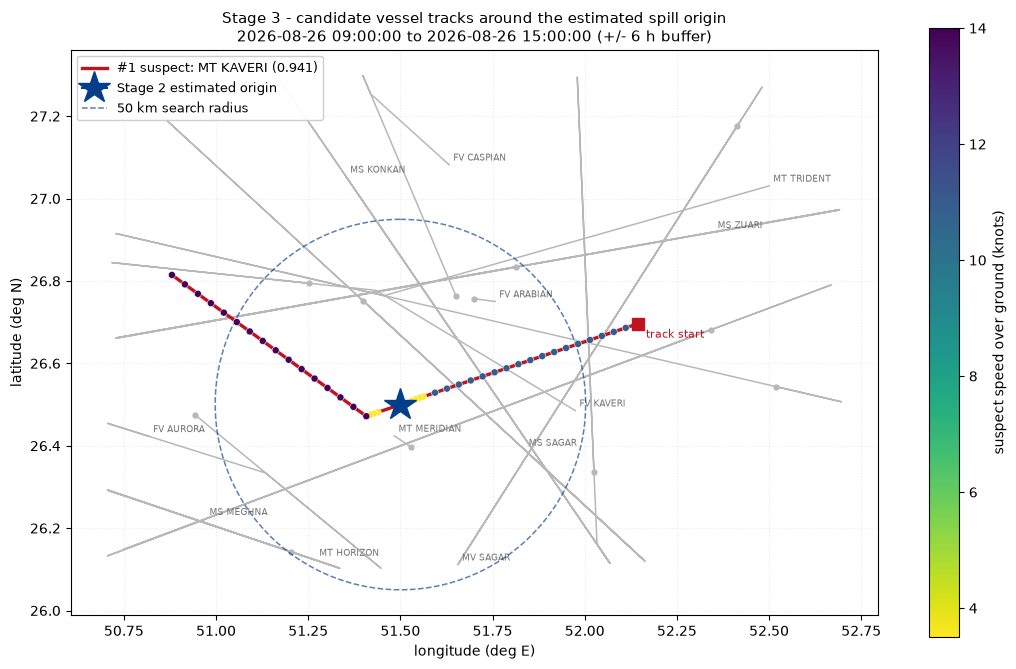

In [10]:
fig, ax = plt.subplots(figsize=(11, 9))

# Every candidate that is not the top suspect.
for mmsi, track in candidates.groupby("MMSI"):
    if mmsi == top["MMSI"]:
        continue
    track = track.sort_values("BaseDateTime")
    ax.plot(track["LON"], track["LAT"], color="0.72", linewidth=1.1, zorder=2)
    ax.plot(track["LON"].iloc[0], track["LAT"].iloc[0], marker="o", color="0.72",
            markersize=3.5, zorder=2)
    ax.annotate(str(track["VesselName"].iloc[0]),
                (track["LON"].iloc[-1], track["LAT"].iloc[-1]),
                fontsize=6.5, color="0.45", xytext=(3, 3), textcoords="offset points")

# The top suspect, drawn on top and coloured by speed so the slowdown shows.
suspect_track = candidates[candidates["MMSI"] == top["MMSI"]].sort_values("BaseDateTime")
ax.plot(suspect_track["LON"], suspect_track["LAT"], color="#c1121f", linewidth=2.4,
        zorder=5, label=f"#1 suspect: {top['VesselName']} ({top['combined_score']:.3f})")
speed_plot = ax.scatter(suspect_track["LON"], suspect_track["LAT"], c=suspect_track["SOG"],
                        cmap="viridis_r", s=26, zorder=6, edgecolor="white", linewidth=0.4)
ax.plot(suspect_track["LON"].iloc[0], suspect_track["LAT"].iloc[0], marker="s",
        color="#c1121f", markersize=8, zorder=7)
ax.annotate("track start", (suspect_track["LON"].iloc[0], suspect_track["LAT"].iloc[0]),
            fontsize=8, color="#c1121f", xytext=(6, -10), textcoords="offset points")

# Stage 2's estimated origin, and the filter radius around it.
ax.plot(ORIGIN_LON, ORIGIN_LAT, marker="*", color="#023e8a", markersize=24, zorder=8,
        label="Stage 2 estimated origin")
circle_bearings = np.linspace(0, 360, 361)
circle = np.array([attr.destination_point(ORIGIN_LON, ORIGIN_LAT, b, 50.0) for b in circle_bearings])
ax.plot(circle[:, 0], circle[:, 1], linestyle="--", color="#023e8a", linewidth=1.1,
        alpha=0.65, zorder=3, label="50 km search radius")

ax.set_xlabel("longitude (deg E)")
ax.set_ylabel("latitude (deg N)")
ax.set_title(f"Stage 3 - candidate vessel tracks around the estimated spill origin\n"
             f"{WINDOW_START} to {WINDOW_END} (+/- 6 h buffer)", fontsize=11)
ax.grid(alpha=0.25, linestyle=":")
ax.set_aspect(1.0 / np.cos(np.radians(ORIGIN_LAT)))   # keep 1 km east = 1 km north
ax.legend(loc="upper left", fontsize=9, framealpha=0.95)
fig.colorbar(speed_plot, ax=ax, label="suspect speed over ground (knots)", shrink=0.7)
plt.tight_layout()
plt.show()

### Zoomed in on the origin

The same picture within about 25 km of the estimated origin, where the ranking is
actually decided. The suspect's slowdown (dark points) and the break in its track
where AIS stopped reporting are both visible here.

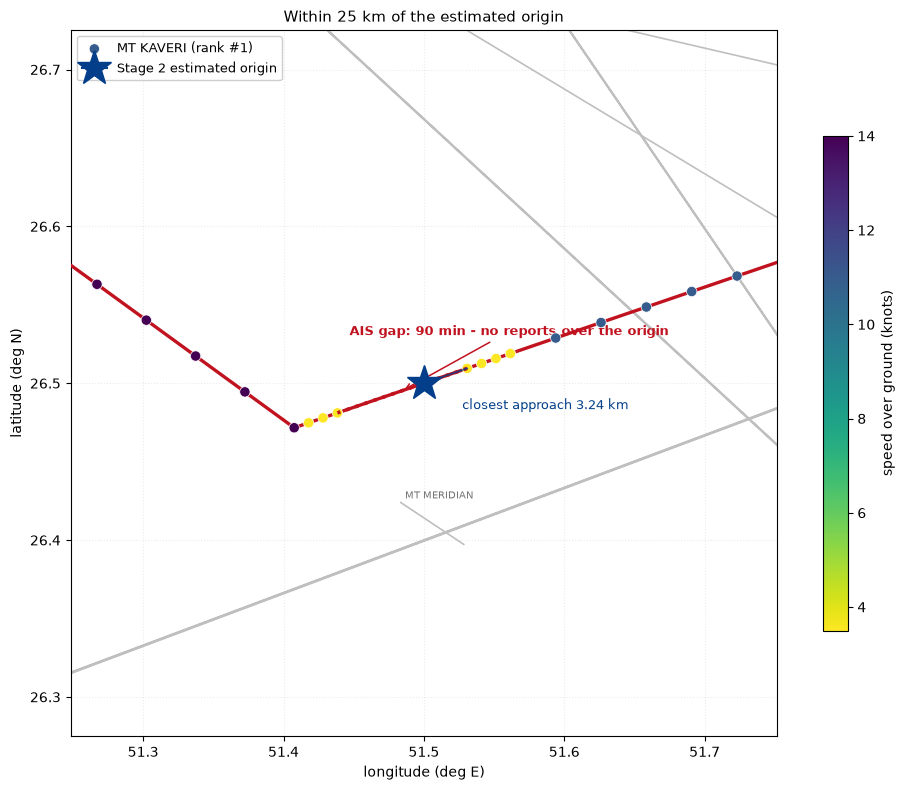

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
ZOOM_KM = 25.0

for mmsi, track in candidates.groupby("MMSI"):
    if mmsi == top["MMSI"]:
        continue
    track = track.sort_values("BaseDateTime")
    ax.plot(track["LON"], track["LAT"], color="0.75", linewidth=1.2, zorder=2)
    ax.annotate(str(track["VesselName"].iloc[0]),
                (track["LON"].iloc[-1], track["LAT"].iloc[-1]),
                fontsize=7, color="0.45", xytext=(3, 3), textcoords="offset points")

ax.plot(suspect_track["LON"], suspect_track["LAT"], color="#c1121f", linewidth=2.4, zorder=5)
speed_plot = ax.scatter(suspect_track["LON"], suspect_track["LAT"], c=suspect_track["SOG"],
                        cmap="viridis_r", s=55, zorder=6, edgecolor="white", linewidth=0.5,
                        label=f"{top['VesselName']} (rank #1)")

# Mark where the AIS gap falls, using the two reports either side of it.
intervals = suspect_track["BaseDateTime"].diff().dt.total_seconds() / 60.0
if intervals.max() > attr.AIS_GAP_MIN_MINUTES:
    gap_end_index = int(intervals.reset_index(drop=True).idxmax())   # idxmax skips the leading NaN
    gap_rows = suspect_track.iloc[gap_end_index - 1: gap_end_index + 1]
    ax.plot(gap_rows["LON"], gap_rows["LAT"], linestyle=":", color="#c1121f", linewidth=2.6, zorder=7)
    ax.annotate(f"AIS gap: {intervals.max():.0f} min - no reports over the origin",
                (gap_rows["LON"].mean(), gap_rows["LAT"].mean()),
                fontsize=9, color="#c1121f", fontweight="bold",
                xytext=(-38, 40), textcoords="offset points",
                arrowprops=dict(arrowstyle="->", color="#c1121f", linewidth=1.1))

ax.plot(ORIGIN_LON, ORIGIN_LAT, marker="*", color="#023e8a", markersize=26, zorder=8,
        label="Stage 2 estimated origin")
closest = suspect_track.iloc[int(np.argmin(attr.haversine_km(
    suspect_track["LON"].to_numpy(), suspect_track["LAT"].to_numpy(), ORIGIN_LON, ORIGIN_LAT)))]
ax.plot([ORIGIN_LON, closest["LON"]], [ORIGIN_LAT, closest["LAT"]],
        linestyle="-", color="#023e8a", linewidth=1.2, alpha=0.8, zorder=7)
ax.annotate(f"closest approach {top['closest_distance_km']:.2f} km",
            ((ORIGIN_LON + closest["LON"]) / 2, (ORIGIN_LAT + closest["LAT"]) / 2),
            fontsize=9, color="#023e8a", xytext=(12, -24), textcoords="offset points")

span_deg = ZOOM_KM / 111.0
ax.set_xlim(ORIGIN_LON - span_deg / np.cos(np.radians(ORIGIN_LAT)),
            ORIGIN_LON + span_deg / np.cos(np.radians(ORIGIN_LAT)))
ax.set_ylim(ORIGIN_LAT - span_deg, ORIGIN_LAT + span_deg)
ax.set_xlabel("longitude (deg E)")
ax.set_ylabel("latitude (deg N)")
ax.set_title(f"Within {ZOOM_KM:.0f} km of the estimated origin", fontsize=11)
ax.grid(alpha=0.25, linestyle=":")
ax.set_aspect(1.0 / np.cos(np.radians(ORIGIN_LAT)))
ax.legend(loc="upper left", fontsize=9, framealpha=0.95)
fig.colorbar(speed_plot, ax=ax, label="speed over ground (knots)", shrink=0.7)
plt.tight_layout()
plt.show()

---
## 7. The suspect's behaviour over time

The map shows *where*; this shows *when*. Speed, distance to the origin and
reporting gaps are plotted against time, with the estimated spill window shaded.
The pattern the anomaly score is built to catch - slow down, stop reporting,
turn away, speed up - reads directly off these panels.

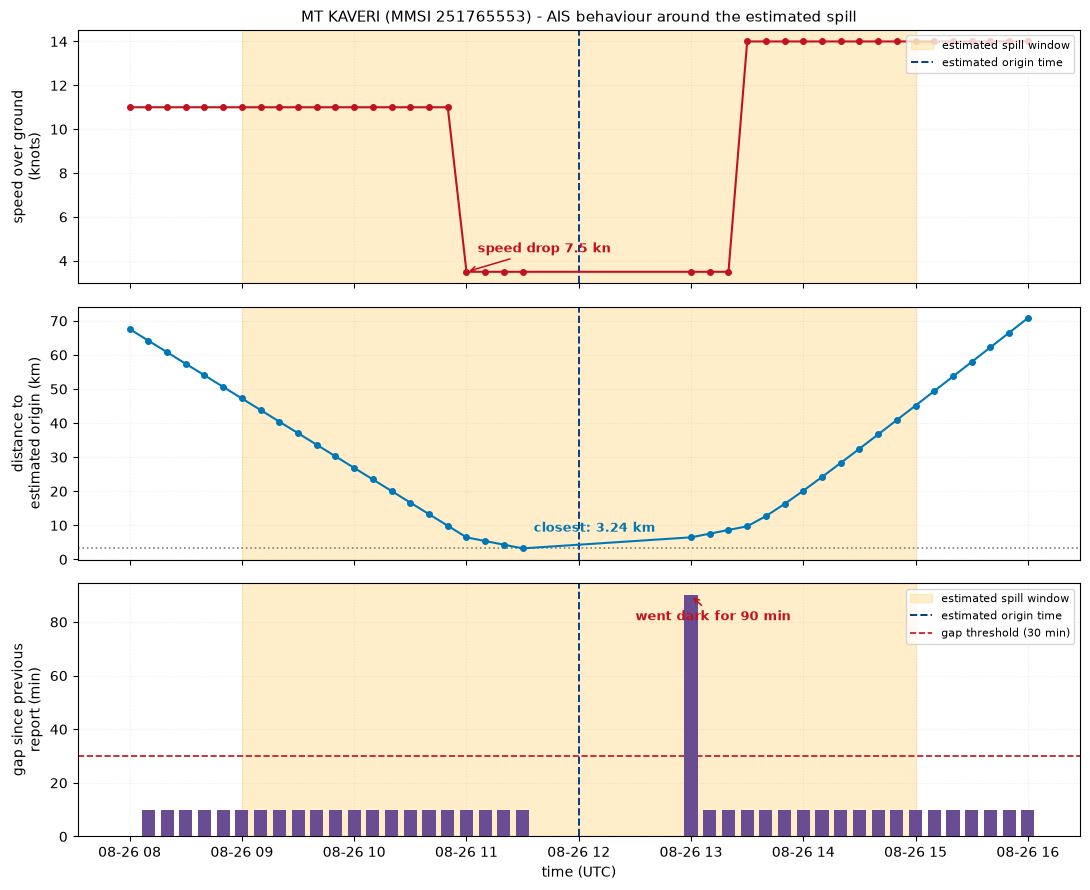

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

track = suspect_track.copy()
track["distance_km"] = attr.haversine_km(
    track["LON"].to_numpy(), track["LAT"].to_numpy(), ORIGIN_LON, ORIGIN_LAT)
track["interval_min"] = track["BaseDateTime"].diff().dt.total_seconds() / 60.0
origin_time = pd.Timestamp(GROUND_TRUTH["true_origin_time"])

for ax in axes:
    ax.axvspan(WINDOW_START, WINDOW_END, color="#ffd166", alpha=0.35, zorder=1,
               label="estimated spill window")
    ax.axvline(origin_time, color="#023e8a", linestyle="--", linewidth=1.4, zorder=2,
               label="estimated origin time")
    ax.grid(alpha=0.25, linestyle=":")

axes[0].plot(track["BaseDateTime"], track["SOG"], marker="o", markersize=4,
             color="#c1121f", zorder=3)
axes[0].set_ylabel("speed over ground\n(knots)")
axes[0].set_title(f"{top['VesselName']} (MMSI {top['MMSI']}) - AIS behaviour around the estimated spill",
                  fontsize=11)
axes[0].legend(loc="upper right", fontsize=8)
if track["SOG"].notna().any():
    drop_index = int((track["SOG"].shift(1) - track["SOG"]).idxmax())
    axes[0].annotate(f"speed drop {ad['speed_drop_knots']} kn",
                     (track.loc[drop_index, "BaseDateTime"], track.loc[drop_index, "SOG"]),
                     fontsize=9, color="#c1121f", fontweight="bold",
                     xytext=(8, 14), textcoords="offset points",
                     arrowprops=dict(arrowstyle="->", color="#c1121f", linewidth=1.1))

axes[1].plot(track["BaseDateTime"], track["distance_km"], marker="o", markersize=4,
             color="#0077b6", zorder=3)
axes[1].axhline(top["closest_distance_km"], color="0.5", linestyle=":", linewidth=1.2)
axes[1].set_ylabel("distance to\nestimated origin (km)")
axes[1].annotate(f"closest: {top['closest_distance_km']:.2f} km",
                 (pd.Timestamp(top["closest_approach_time"]), top["closest_distance_km"]),
                 fontsize=9, color="#0077b6", fontweight="bold",
                 xytext=(8, 12), textcoords="offset points")

axes[2].bar(track["BaseDateTime"], track["interval_min"].fillna(0),
            width=pd.Timedelta(minutes=7), color="#6a4c93", zorder=3)
axes[2].axhline(attr.AIS_GAP_MIN_MINUTES, color="#c1121f", linestyle="--", linewidth=1.2,
                label=f"gap threshold ({attr.AIS_GAP_MIN_MINUTES:.0f} min)")
axes[2].set_ylabel("gap since previous\nreport (min)")
axes[2].set_xlabel("time (UTC)")
axes[2].legend(loc="upper right", fontsize=8)
if track["interval_min"].max() > attr.AIS_GAP_MIN_MINUTES:
    gap_row = track.loc[track["interval_min"].idxmax()]
    axes[2].annotate(f"went dark for {gap_row['interval_min']:.0f} min",
                     (gap_row["BaseDateTime"], gap_row["interval_min"]),
                     fontsize=9, color="#c1121f", fontweight="bold",
                     xytext=(-40, -18), textcoords="offset points",
                     arrowprops=dict(arrowstyle="->", color="#c1121f", linewidth=1.1))

plt.tight_layout()
plt.show()

### The same three panels for the runner-up

Useful as a control: the second-ranked vessel was also nearby, but its speed is
steady, it reports continuously, and its distance curve never dips as low. This
is the difference the anomaly and proximity terms are measuring.

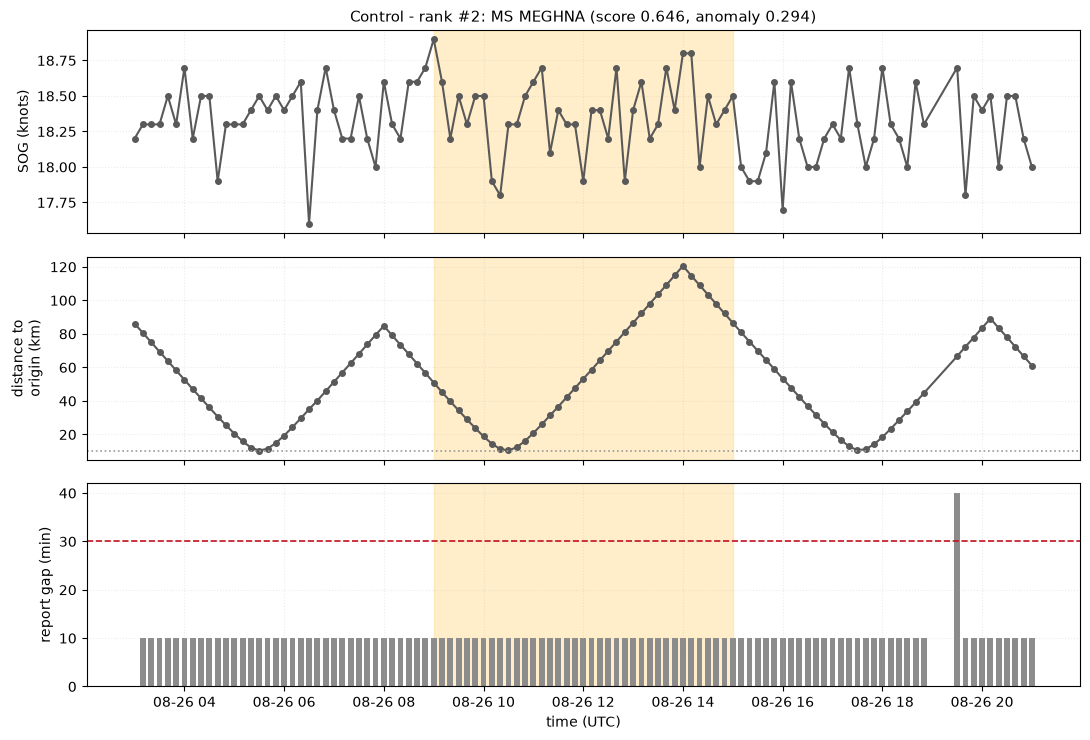

In [13]:
control_track = candidates[candidates["MMSI"] == runner_up["MMSI"]].sort_values("BaseDateTime").copy()
control_track["distance_km"] = attr.haversine_km(
    control_track["LON"].to_numpy(), control_track["LAT"].to_numpy(), ORIGIN_LON, ORIGIN_LAT)
control_track["interval_min"] = control_track["BaseDateTime"].diff().dt.total_seconds() / 60.0

fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)
for ax in axes:
    ax.axvspan(WINDOW_START, WINDOW_END, color="#ffd166", alpha=0.35, zorder=1)
    ax.grid(alpha=0.25, linestyle=":")

axes[0].plot(control_track["BaseDateTime"], control_track["SOG"], marker="o", markersize=4, color="0.35")
axes[0].set_ylabel("SOG (knots)")
axes[0].set_title(f"Control - rank #{runner_up['rank']}: {runner_up['VesselName']} "
                  f"(score {runner_up['combined_score']:.3f}, anomaly {runner_up['anomaly_score']:.3f})",
                  fontsize=11)
axes[1].plot(control_track["BaseDateTime"], control_track["distance_km"], marker="o",
             markersize=4, color="0.35")
axes[1].axhline(runner_up["closest_distance_km"], color="0.6", linestyle=":", linewidth=1.2)
axes[1].set_ylabel("distance to\norigin (km)")
axes[2].bar(control_track["BaseDateTime"], control_track["interval_min"].fillna(0),
            width=pd.Timedelta(minutes=7), color="0.55")
axes[2].axhline(attr.AIS_GAP_MIN_MINUTES, color="#c1121f", linestyle="--", linewidth=1.2)
axes[2].set_ylabel("report gap (min)")
axes[2].set_xlabel("time (UTC)")
plt.tight_layout()
plt.show()

---
## 8. Does it hold up, or did it work once?

One passing scenario proves very little. These checks re-run the whole pipeline
across many randomised fleets, and against deliberately degraded inputs, to see
where the scoring holds and where it breaks. The failure points are as
informative as the successes and are carried into the README's limitations.

In [14]:
# A. Many randomised scenarios: is the planted culprit reliably #1?
warnings.simplefilter("ignore")
N_SEEDS = 25
seed_rows = []
for seed in range(N_SEEDS):
    seed_df, seed_truth = attr.generate_synthetic_ais_data(seed=seed)
    seed_suspects = attr.rank_vessels(seed_df, ORIGIN_LON, ORIGIN_LAT, WINDOW_START, WINDOW_END)
    hit = next((s for s in seed_suspects if s["MMSI"] == seed_truth["suspect_mmsi"]), None)
    seed_rows.append({
        "seed": seed,
        "culprit": seed_truth["suspect_name"],
        "rank": hit["rank"] if hit else None,
        "score": hit["combined_score"] if hit else 0.0,
        "runner_up": seed_suspects[1]["combined_score"] if len(seed_suspects) > 1 else 0.0,
        "candidates": len(seed_suspects),
    })

seed_results = pd.DataFrame(seed_rows)
seed_results["margin"] = seed_results["score"] - seed_results["runner_up"]
top1_accuracy = float((seed_results["rank"] == 1).mean())

print(seed_results.round(3).to_string(index=False))
print(f"\ntop-1 accuracy over {N_SEEDS} scenarios: {top1_accuracy:.0%}")
print(f"margin over runner-up: mean {seed_results['margin'].mean():+.3f}, "
      f"min {seed_results['margin'].min():+.3f}, max {seed_results['margin'].max():+.3f}")

 seed     culprit  rank  score  runner_up  candidates  margin
    0    MT ATLAS     1  0.938      0.671          12   0.267
    1  MT HORIZON     1  0.940      0.652          14   0.288
    2  MT VINDHYA     1  0.940      0.493           6   0.447
    3    MT SAGAR     1  0.939      0.674          12   0.265
    4   MT DECCAN     1  0.941      0.718          12   0.222
    5  MT SATPURA     1  0.939      0.698          11   0.241
    6 MT MERIDIAN     1  0.939      0.656           8   0.282
    7    MT ATLAS     1  0.940      0.715          15   0.225
    8    MT CORAL     1  0.943      0.595          12   0.349
    9   MT DECCAN     1  0.939      0.552          11   0.387
   10    MT ZUARI     1  0.941      0.728          11   0.213
   11   MT MEGHNA     1  0.940      0.670          13   0.270
   12  MT VINDHYA     1  0.940      0.712          12   0.227
   13   MT DECCAN     1  0.941      0.731          15   0.210
   14  MT NILGIRI     1  0.939      0.700          12   0.238
   15  M

In [15]:
# B. Stage 2 will not hand over a perfect origin. How much error is tolerable?
origin_rows = []
for offset_km in [0, 2, 5, 10, 20, 40]:
    off_lon, off_lat = attr.destination_point(ORIGIN_LON, ORIGIN_LAT, 45.0, offset_km)
    shifted = attr.rank_vessels(ais_df, off_lon, off_lat, WINDOW_START, WINDOW_END)
    hit = next((s for s in shifted if s["MMSI"] == GROUND_TRUTH["suspect_mmsi"]), None)
    origin_rows.append({
        "origin_error_km": offset_km,
        "culprit_rank": hit["rank"] if hit else None,
        "score": round(hit["combined_score"], 3) if hit else 0.0,
        "proximity": round(hit["proximity_score"], 3) if hit else 0.0,
        "trajectory": round(hit["trajectory_score"], 3) if hit else 0.0,
        "candidates": len(shifted),
    })
print("Origin displaced north-east by:")
print(pd.DataFrame(origin_rows).to_string(index=False))

Origin displaced north-east by:
 origin_error_km  culprit_rank  score  proximity  trajectory  candidates
               0             1  0.941      0.954       0.999          13
               2             1  0.951      0.986       0.997          13
               5             1  0.943      0.975       0.980          13
              10             1  0.917      0.929       0.949          13
              20             1  0.865      0.839       0.879          13
              40             2  0.734      0.661       0.653          15


In [16]:
# C. The estimated time window will also be off. How far can it slide?
time_rows = []
for shift_hours in [-9, -6, -3, 0, 3, 6, 9]:
    shifted_start = pd.Timestamp(WINDOW_START) + pd.Timedelta(hours=shift_hours)
    shifted_end = pd.Timestamp(WINDOW_END) + pd.Timedelta(hours=shift_hours)
    shifted = attr.rank_vessels(ais_df, ORIGIN_LON, ORIGIN_LAT, shifted_start, shifted_end)
    hit = next((s for s in shifted if s["MMSI"] == GROUND_TRUTH["suspect_mmsi"]), None)
    time_rows.append({
        "window_shift_h": shift_hours,
        "culprit_rank": hit["rank"] if hit else None,
        "score": round(hit["combined_score"], 3) if hit else 0.0,
        "anomaly": round(hit["anomaly_score"], 3) if hit else 0.0,
        "reports_in_scan": hit["anomaly_detail"]["reports_in_scan_window"] if hit else 0,
    })
print("Spill window slid by:")
print(pd.DataFrame(time_rows).to_string(index=False))
print("\nThe anomaly score collapses once the window no longer overlaps the discharge:")
print("the behavioural evidence is simply outside the scan range.")

Spill window slid by:
 window_shift_h  culprit_rank  score  anomaly  reports_in_scan
             -9             1  0.736    0.009                7
             -6             1  0.818    0.339               22
             -3             1  0.941    0.828               35
              0             1  0.941    0.828               41
              3             1  0.941    0.828               35
              6             1  0.792    0.233               19
              9             9  0.412    0.005                7

The anomaly score collapses once the window no longer overlaps the discharge:
the behavioural evidence is simply outside the scan range.


In [17]:
# D. Which factors are doing the work? Re-rank with factors switched off.
ablations = {
    "all four (default)": None,
    "proximity only":     {"proximity": 1, "trajectory": 0, "anomaly": 0, "vessel_type": 0},
    "trajectory only":    {"proximity": 0, "trajectory": 1, "anomaly": 0, "vessel_type": 0},
    "anomaly only":       {"proximity": 0, "trajectory": 0, "anomaly": 1, "vessel_type": 0},
    "vessel type only":   {"proximity": 0, "trajectory": 0, "anomaly": 0, "vessel_type": 1},
    "no anomaly term":    {"proximity": 0.45, "trajectory": 0.40, "anomaly": 0.0, "vessel_type": 0.15},
    "no vessel type":     {"proximity": 0.39, "trajectory": 0.33, "anomaly": 0.28, "vessel_type": 0.0},
}
ablation_rows = []
for label, weight_override in ablations.items():
    ranked = attr.rank_vessels(ais_df, ORIGIN_LON, ORIGIN_LAT, WINDOW_START, WINDOW_END,
                               weights=weight_override)
    hit = next((s for s in ranked if s["MMSI"] == GROUND_TRUTH["suspect_mmsi"]), None)
    runner = ranked[1]["combined_score"] if len(ranked) > 1 else 0.0
    ablation_rows.append({
        "weights": label,
        "culprit_rank": hit["rank"] if hit else None,
        "culprit_score": round(hit["combined_score"], 3) if hit else 0.0,
        "runner_up": round(runner, 3),
        "margin": round(ranked[0]["combined_score"] - runner, 3),
    })
print(pd.DataFrame(ablation_rows).to_string(index=False))
print("\nEvery factor alone puts the culprit first in this scenario, but the margins differ:")
print("the anomaly term separates it most, and vessel type alone cannot separate tankers at all.")

           weights  culprit_rank  culprit_score  runner_up  margin
all four (default)             1          0.941      0.646   0.294
    proximity only             1          0.954      0.845   0.110
   trajectory only             1          0.999      0.900   0.099
      anomaly only             1          0.828      0.298   0.530
  vessel type only             1          1.000      1.000   0.000
   no anomaly term             1          0.979      0.753   0.226
    no vessel type             1          0.934      0.694   0.239

Every factor alone puts the culprit first in this scenario, but the margins differ:
the anomaly term separates it most, and vessel type alone cannot separate tankers at all.


In [18]:
# E. Real feeds are missing columns. Does it degrade or fall over?
degraded_rows = []
variants = {
    "full schema": ais_df,
    "minimum viable (no COG/type)": ais_df[["MMSI", "BaseDateTime", "LAT", "LON", "SOG"]],
    "no SOG (no speed anomaly)": ais_df.drop(columns=["SOG"]),
    "no VesselType (no prior)": ais_df.drop(columns=["VesselType"]),
    "positions only": ais_df[["MMSI", "BaseDateTime", "LAT", "LON"]],
}
for label, variant in variants.items():
    ranked = attr.rank_vessels(variant, ORIGIN_LON, ORIGIN_LAT, WINDOW_START, WINDOW_END)
    hit = next((s for s in ranked if s["MMSI"] == GROUND_TRUTH["suspect_mmsi"]), None)
    degraded_rows.append({
        "AIS columns available": label,
        "culprit_rank": hit["rank"] if hit else None,
        "score": round(hit["combined_score"], 3) if hit else 0.0,
        "traj": round(hit["trajectory_score"], 3) if hit else 0.0,
        "anom": round(hit["anomaly_score"], 3) if hit else 0.0,
        "course from": hit["course_source"] if hit else "-",
    })
print(pd.DataFrame(degraded_rows).to_string(index=False))
print("\nWith no COG or Heading the course is derived from consecutive positions,")
print("so trajectory scoring still works on position data alone.")

       AIS columns available  culprit_rank  score  traj  anom        course from
                 full schema             1  0.941 0.999 0.828                COG
minimum viable (no COG/type)             1  0.880 1.000 0.824 derived from track
   no SOG (no speed anomaly)             1  0.859 0.999 0.500                COG
    no VesselType (no prior)             1  0.881 0.999 0.828                COG
              positions only             1  0.798 1.000 0.496 derived from track



With no COG or Heading the course is derived from consecutive positions,
so trajectory scoring still works on position data alone.


---
## 9. Save a results summary

Stage 1 wrote `training_results.json`; Stage 3 writes the same kind of record so
the numbers quoted in the submission document can be traced back to a run rather
than retyped from memory.

In [19]:
results = {
    "stage": "3 - vessel attribution (AIS correlation)",
    "project": "oiltrace / SpillTrace",
    "problem_statement": "SIH26143 (NTRO)",
    "method": "rule-based multi-factor scoring - not a trained model",
    "entry_point": "attribution.rank_vessels()",
    "scenario": {
        "region": "Central Persian Gulf, north of Qatar (Stage 2 demo scenario)",
        "estimated_origin_lon": ORIGIN_LON,
        "estimated_origin_lat": ORIGIN_LAT,
        "estimated_origin_time": str(GROUND_TRUTH["true_origin_time"]),
        "spill_window": [str(WINDOW_START), str(WINDOW_END)],
        "search_radius_km": 50.0,
        "time_buffer_hours": 6.0,
    },
    "data": {
        "source": "synthetic (attribution.generate_synthetic_ais_data)",
        "is_real_ais": False,
        "file": str(AIS_CSV).replace("\\", "/"),
        "reports": int(len(ais_df)),
        "vessels": int(ais_df["MMSI"].nunique()),
        "report_interval_minutes": GROUND_TRUTH["report_interval_minutes"],
        "real_data_path_when_available": "https://marinecadastre.gov/accessais",
    },
    "scoring_weights": dict(attr.DEFAULT_WEIGHTS),
    "anomaly_sub_weights": dict(attr.ANOMALY_SUB_WEIGHTS),
    "demo_run": {
        "candidates_after_filter": len(suspects),
        "planted_culprit": GROUND_TRUTH["suspect_name"],
        "planted_culprit_mmsi": GROUND_TRUTH["suspect_mmsi"],
        "culprit_rank": top["rank"],
        "culprit_score": top["combined_score"],
        "culprit_sub_scores": {
            "proximity": top["proximity_score"],
            "trajectory": top["trajectory_score"],
            "anomaly": top["anomaly_score"],
            "vessel_type": top["vessel_type_score"],
        },
        "culprit_closest_approach_km": top["closest_distance_km"],
        "runner_up": runner_up["VesselName"],
        "runner_up_score": runner_up["combined_score"],
        "margin": round(top["combined_score"] - runner_up["combined_score"], 4),
    },
    "validation": {
        "randomised_scenarios": N_SEEDS,
        "top1_accuracy": round(top1_accuracy, 4),
        "mean_margin_over_runner_up": round(float(seed_results["margin"].mean()), 4),
        "min_margin_over_runner_up": round(float(seed_results["margin"].min()), 4),
        "origin_error_tolerance": origin_rows,
        "time_window_shift_tolerance": time_rows,
        "factor_ablation": ablation_rows,
        "missing_column_degradation": degraded_rows,
    },
    "limitations": [
        "AIS data here is synthetic; the planted culprit makes the scoring testable but "
        "does not prove accuracy on real traffic.",
        "Attribution is probabilistic - the output ranks suspects to investigate and is "
        "not an identification.",
        "Vessels can switch off AIS entirely; a vessel with no reports cannot be ranked at all.",
        "Accuracy is bounded by Stage 2's estimate: at 40 km of origin error the culprit's "
        "score falls from 0.94 to 0.74 and it slips to rank 2, and a window slid 9 h late - "
        "past the discharge entirely - drops it to rank 9.",
        "AIS gap thresholds assume a roughly 10-minute reporting cadence and must be "
        "retuned for feeds that report less often.",
    ],
}

results_path = Path("attribution_results.json")
results_path.write_text(json.dumps(results, indent=2), encoding="utf-8")
print(f"wrote {results_path}  ({results_path.stat().st_size / 1024:.1f} KB)")
print(json.dumps({k: results[k] for k in ["stage", "method", "entry_point", "scoring_weights"]}, indent=2))
print()
print(json.dumps(results["demo_run"], indent=2))

wrote attribution_results.json  (7.0 KB)
{
  "stage": "3 - vessel attribution (AIS correlation)",
  "method": "rule-based multi-factor scoring - not a trained model",
  "entry_point": "attribution.rank_vessels()",
  "scoring_weights": {
    "proximity": 0.35,
    "trajectory": 0.3,
    "anomaly": 0.25,
    "vessel_type": 0.1
  }
}

{
  "candidates_after_filter": 13,
  "planted_culprit": "MT KAVERI",
  "planted_culprit_mmsi": "251765553",
  "culprit_rank": 1,
  "culprit_score": 0.9406,
  "culprit_sub_scores": {
    "proximity": 0.9543,
    "trajectory": 0.9986,
    "anomaly": 0.8281,
    "vessel_type": 1.0
  },
  "culprit_closest_approach_km": 3.241,
  "runner_up": "MS MEGHNA",
  "runner_up_score": 0.6461,
  "margin": 0.2945
}


---
## 10. Backend integration

`rank_vessels()` is the only function the backend needs. Chained across the three
stages:

```python
from ml.detection.detection import predict_oil_spill   # Stage 1
from ml.drift_trace.drift_trace import trace_origin    # Stage 2
from ml.attribution.attribution import rank_vessels    # Stage 3

mask = predict_oil_spill(image_path, model, device)
origin = trace_origin(detection_lon, detection_lat, detection_time)

# Stage 2 returns a single best-estimate release time, not a window
# (its keys: estimated_origin_lon/lat, estimated_origin_time, stranded_early),
# so widen it into the window Stage 3 wants - 3 h either side by default.
origin_time = pd.to_datetime(origin["estimated_origin_time"])
suspects = rank_vessels(
    ais_df="data/synthetic_ais_persian_gulf.csv",
    origin_lon=origin["estimated_origin_lon"],
    origin_lat=origin["estimated_origin_lat"],
    time_window_start=origin_time - timedelta(hours=3),
    time_window_end=origin_time + timedelta(hours=3),
)
return suspects            # already JSON-serialisable
```

Every value in a suspect dict is a plain Python type, so FastAPI can return the
list directly with no conversion. An empty list is a valid answer - it means no
vessel was inside the search window, which is a real finding rather than an error.

### Honest framing for the demo and the write-up

* The AIS data is synthetic. The planted culprit makes the scoring **testable**;
  it does not demonstrate accuracy against real traffic.
* The output is a ranked list of suspects with a factor breakdown. Describing it
  as "identifying the responsible vessel" overstates what AIS correlation can do.
* This stage is **rule-based scoring, not machine learning**. That is a
  deliberate choice: the weights are inspectable and every rank can be explained
  to an investigator, which a learned model would not give without training data
  of confirmed spill attributions - data that does not exist for this problem.

See `README.md` in this folder for the scoring methodology, the rationale behind
each weight, and how to swap in real marinecadastre.gov AIS data.